# Geospatial Analysis

## 0. Imports and Setup

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from pygris import tracts

## 1. Load HCV Data and Dallas County Shapefile

In [43]:
df = pd.read_csv("data/clean_hcv_data.csv", dtype={"code": str})
df.head()

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
0,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000401,48113000401,39,297,11131,38,1,2014,0,1
1,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000405,48113000405,17,268,10446,40,1,2014,0,1
2,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000500,48113000500,25,202,8242,17,1,2014,0,0
3,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000601,48113000601,17,336,12377,35,1,2014,0,1
4,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000800,48113000800,123,326,11988,27,1,2014,0,0


In [44]:
# Download tract shapefile for Dallas County (FIPS 48113).
# pygris caches locally after the first download.
dallas_shp = tracts(state="TX", county="113", year=2020, cache=True)
dallas_shp = dallas_shp[["GEOID", "geometry"]].rename(columns={"GEOID": "code"})
print(f"Dallas County: {len(dallas_shp)} tracts in shapefile")

Using FIPS code '48' for input 'TX'
Dallas County: 645 tracts in shapefile


## 2. Build Map Data for 2015 and 2022

For each year we pull `number_reported` (HCV households per tract) and `poverty_indicator` (1 if the tract's poverty rate is at least 30%) and merge them onto the tract geometry. A tract with no value for `number_reported` in a given year has been suppressed by HUD (voucher count below 11) and will be shown in gray.

In [45]:
def build_year(hcv_df, shp, year):
    sub = hcv_df[(hcv_df["year"] == year) & (hcv_df["code"].str.startswith("48113"))]
    return shp.merge(
        sub[["code", "number_reported", "poverty_indicator"]],
        on="code",
        how="left",
    )


dallas_2015 = build_year(df, dallas_shp, 2015)
dallas_2022 = build_year(df, dallas_shp, 2022)

for name, gdf in [("Dallas 2015", dallas_2015), ("Dallas 2022", dallas_2022)]:
    n_data = gdf["number_reported"].notna().sum()
    n_hp = ((gdf["poverty_indicator"] == 1) & gdf["number_reported"].notna()).sum()
    print(
        f"{name}: {n_data} of {len(gdf)} tracts with HCV data; {n_hp} are high-poverty"
    )

Dallas 2015: 214 of 645 tracts with HCV data; 59 are high-poverty
Dallas 2022: 172 of 645 tracts with HCV data; 35 are high-poverty


## 3. Pre vs Post Maps

Two maps side by side, sharing the same color scale so that color intensity can be compared directly between the two years. Tracts classified as high-poverty (`poverty_indicator == 1`) are overlaid with black diagonal hatching. Missing tracts are shown in light gray.

Shared color scale: 0 to 227 HCV households per tract


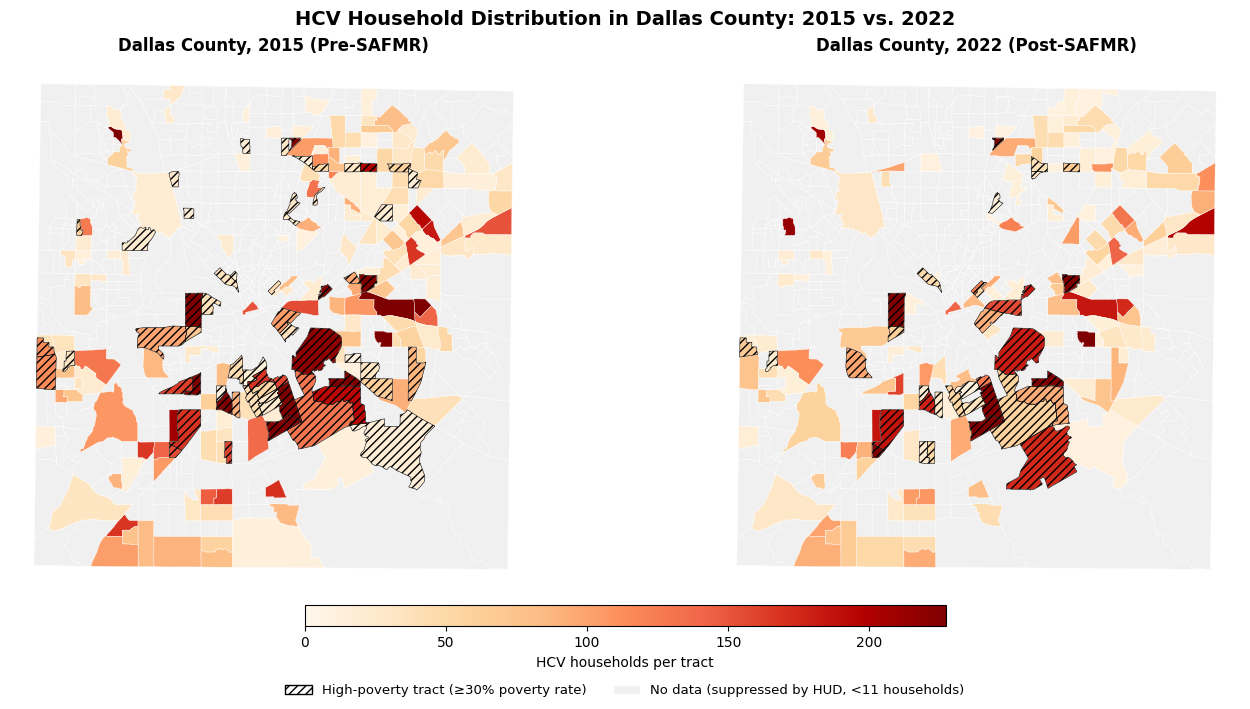

In [ ]:
# Shared color scale across both years, capped at the 95th percentile.
all_vals = pd.concat(
    [dallas_2015["number_reported"], dallas_2022["number_reported"]]
).dropna()
vmin = 0
vmax = np.percentile(all_vals, 95)
print(f"Shared color scale: {vmin} to {vmax:.0f} HCV households per tract")

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

for ax, gdf, title in [
    (axes[0], dallas_2015, "Dallas County, 2015 (Pre-SAFMR)"),
    (axes[1], dallas_2022, "Dallas County, 2022 (Post-SAFMR)"),
]:
    # Light gray base layer for suppressed tracts
    gdf.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.3)

    # HCV households: continuous fill
    has_data = gdf.dropna(subset=["number_reported"])
    has_data.plot(
        ax=ax,
        column="number_reported",
        cmap="OrRd",
        vmin=vmin,
        vmax=vmax,
        edgecolor="white",
        linewidth=0.3,
    )

    # Hatch high-poverty tracts
    high_pov = has_data[has_data["poverty_indicator"] == 1]
    high_pov.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.4,
        hatch="////",
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()

# Shared horizontal colorbar 
sm = plt.cm.ScalarMappable(cmap="OrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    fraction=0.04,
    pad=0.02,
    shrink=0.5,
    aspect=30,
)
cbar.set_label("HCV households per tract", fontsize=10)

# Hatch + suppressed legend, placed below the colorbar
hp_patch = mpatches.Patch(
    facecolor="white",
    edgecolor="black",
    hatch="////",
    label="High-poverty tract (≥30% poverty rate)",
)
nodata_patch = mpatches.Patch(
    facecolor="#f0f0f0",
    edgecolor="white",
    label="No data (suppressed by HUD, <11 households)",
)
fig.legend(
    handles=[hp_patch, nodata_patch],
    loc="outside lower center",
    ncol=2,
    frameon=False,
    fontsize=9.5,
)

fig.suptitle(
    "HCV Household Distribution in Dallas County: 2015 vs. 2022",
    fontsize=14,
    fontweight="bold",
)

plt.show()

### Description

These two maps show where HCV households were located across Dallas County tracts in 2015 (before SAFMR) and 2022 (after SAFMR). Tracts are colored by the number of voucher households living in them; tracts with black diagonal hatching are high-poverty (≥30% of households below the federal poverty line); tracts in light gray were suppressed by HUD that year because they had fewer than 11 voucher households. Both maps use the same color scale, so a tract that goes from dark in 2015 to light in 2022 actually lost voucher families, not just changed in relative terms.

The clearest pattern is in the southern half of the county. In 2015, most of the darkest tracts cluster in south and southwest Dallas, and most of the hatched (high-poverty) tracts sit in the same area, so the voucher population was heavily concentrated in poorer neighborhoods. In 2022 the same area is noticeably lighter overall, and a lot of the hatched tracts that had voucher households in 2015 are now showing up in light gray, meaning they dropped below the HUD reporting threshold of 11 households. The northern and western parts of the county stay light in both years, since they don't have many high-poverty tracts to begin with. The maps fit a story where voucher families are slowly leaving the poorer parts of Dallas where they used to be concentrated, but the maps alone can't prove that SAFMRs caused the change.
